In [1]:
import numpy as np
from tabpfn import TabPFNRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (RBF, Matern, RationalQuadratic, 
                                           ExpSineSquared, ConstantKernel)
from sklearn.model_selection import GridSearchCV
from matplotlib import pyplot as plt
from itertools import combinations

In [2]:
from matplotlib import rcParams
# rcParams['font.family'] = 'arial'
rcParams['mathtext.fontset'] = 'dejavuserif'
# rcParams['mathtext.rm'] = 'arial'
# rcParams['mathtext.it'] = 'arial:italic'
# rcParams['mathtext.bf'] = 'arial:bold'
rcParams['axes.titlepad'] = 12
rcParams['axes.labelsize'] = 20
rcParams['axes.titlesize'] = 25
rcParams['figure.dpi'] = 100
rcParams['figure.figsize'] = [7.8, 5.8]
rcParams['figure.titlesize'] = 25
rcParams['font.size'] = 20.0
rcParams['legend.fontsize'] = 20
# rcParams['legend.frameon'] = False
rcParams['xtick.labelsize'] = 17
rcParams['ytick.labelsize'] = 17

## How TabPFN extrapolate in 1D?

In [3]:
def linear(x):
    return x

def quadratic(x):
    return x**2

def step(x):
    return np.array([0 if t<0 else 1 for t in x])

def piecewise_linear(x):
    """
    Create piecewise linear function connecting specified points
    
    Parameters:
    x : array-like - Input values
    breakpoints : list - x-coordinates of breakpoints (must include 0 and 1)
    values : list - y-values at breakpoints
    """
    breakpoints = [-1, -0.6, 0.2, 0.6, 1]
    values = [0, 1, -0.5, 0.7, 0]
    breakpoints = np.array(breakpoints)
    values = np.array(values)
    return np.interp(x, breakpoints, values)

0.05 -7.28926935419653
0.1 -0.11657762339043032
0.15 0.18244348567880664
0.2 -0.8961406799071447
0.05 -4.5515942175293915
0.1 -1.3559625331361929
0.15 -0.8650761901135819
0.2 -1.7723911999243658
0.05 -4.852574070312837


/root/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/root/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


0.1 -0.11658508221494834
0.15 0.1824368407018735


/root/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


0.2 -0.8961468321737147
0.05 -10.99138767591247
0.1 -0.1165776783528365
0.15 0.18244345234171
0.2 -0.8961406944705708


...

0.2 1.9569889898520891
0.05 -16.15008502697735
0.1 6.014725590438623
0.15 5.858179599276831
0.2 2.495353776324052


/root/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


0.05 6.052838762790024
0.1 6.052838762852474
0.15 5.133866542647603


/root/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


0.2 1.956996327922262


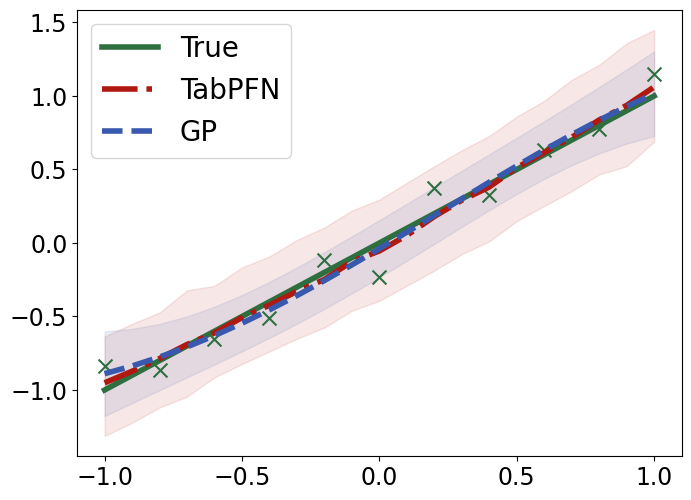

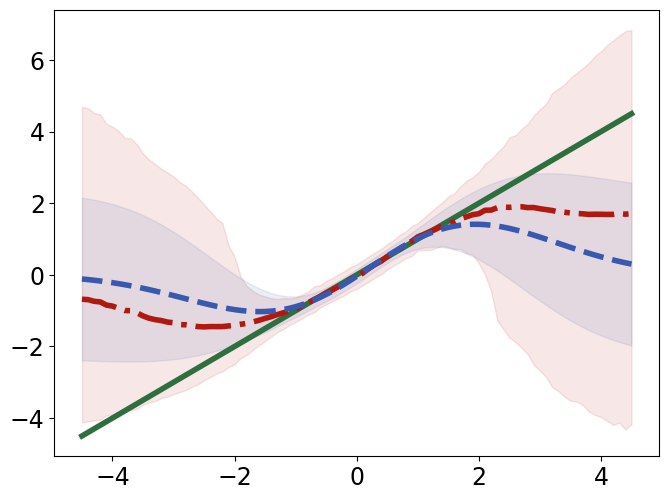

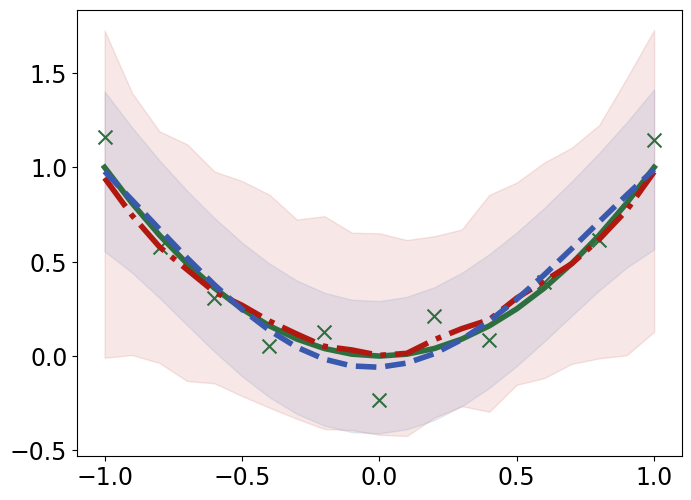

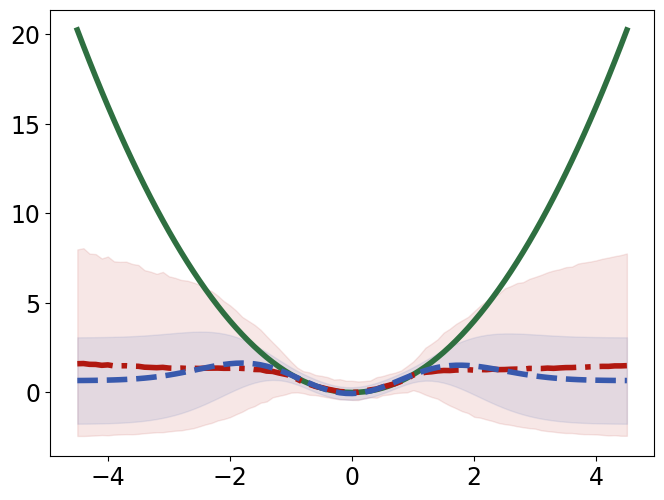

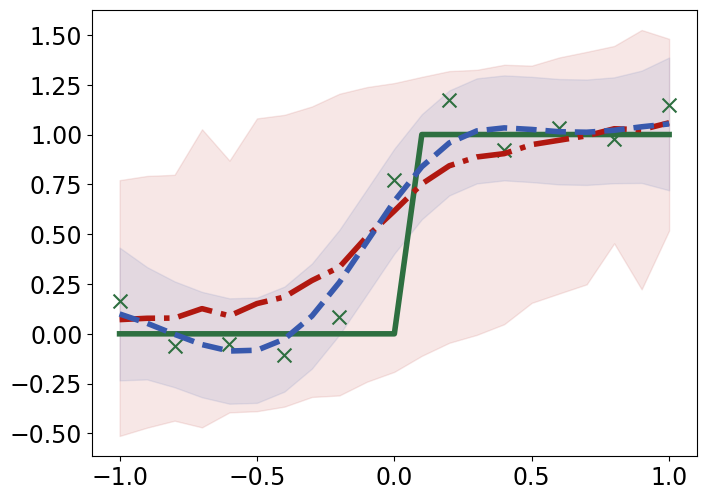

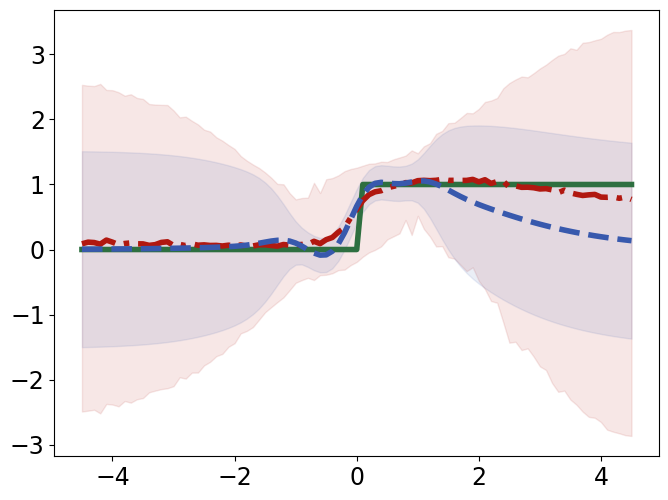

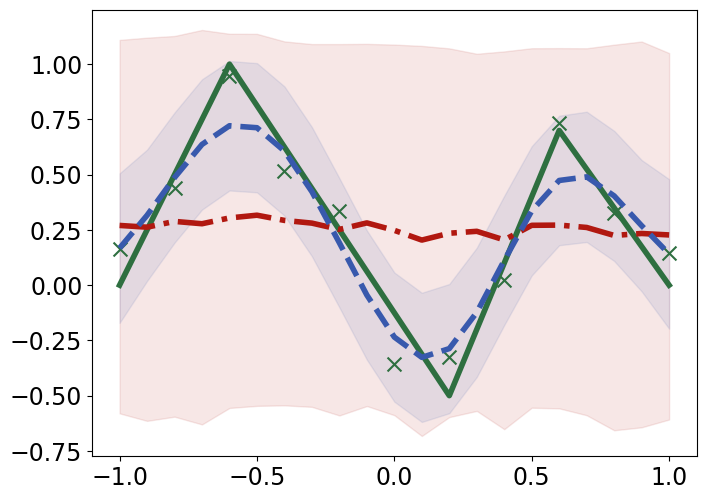

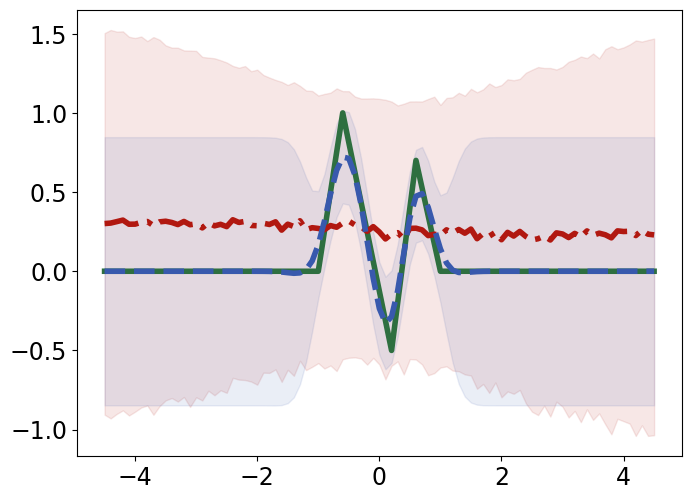

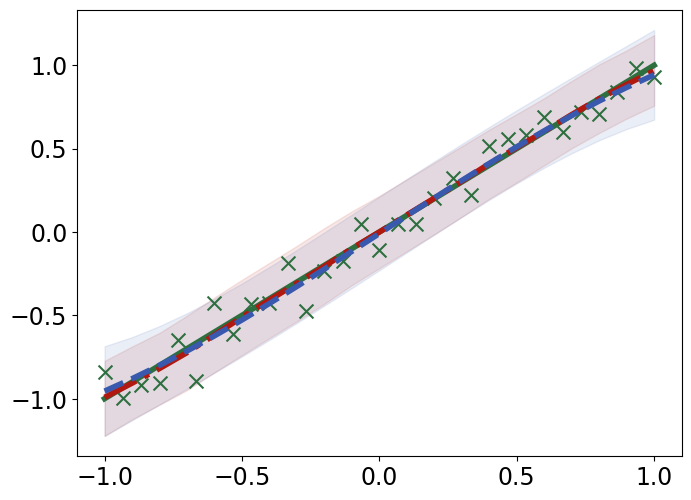

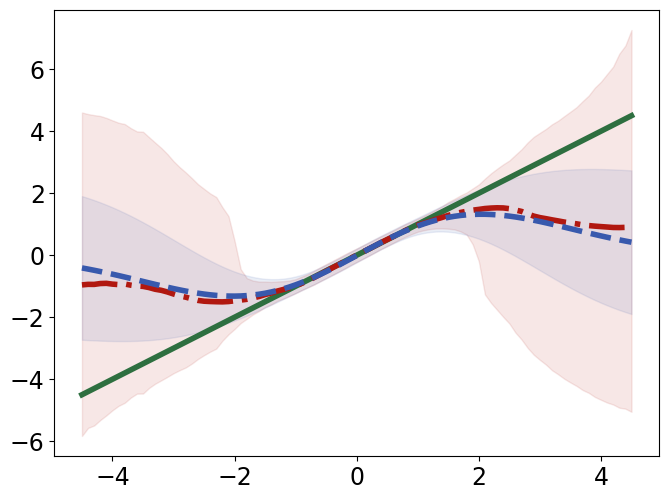

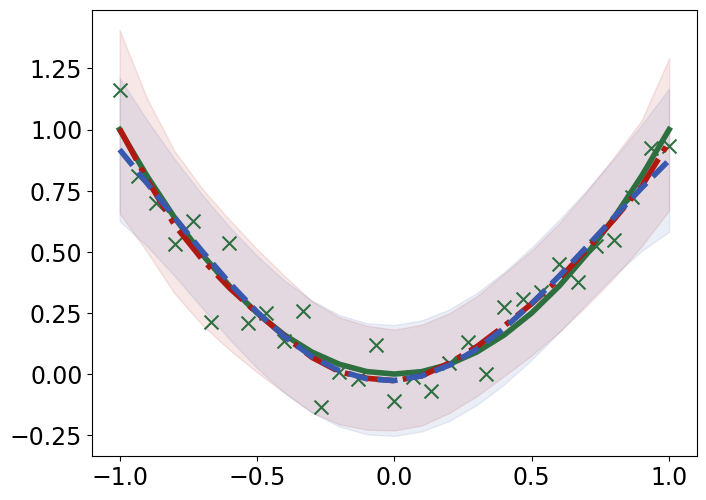

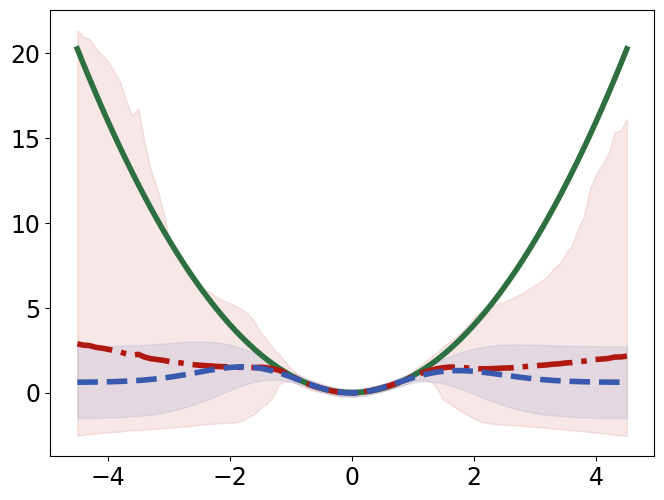

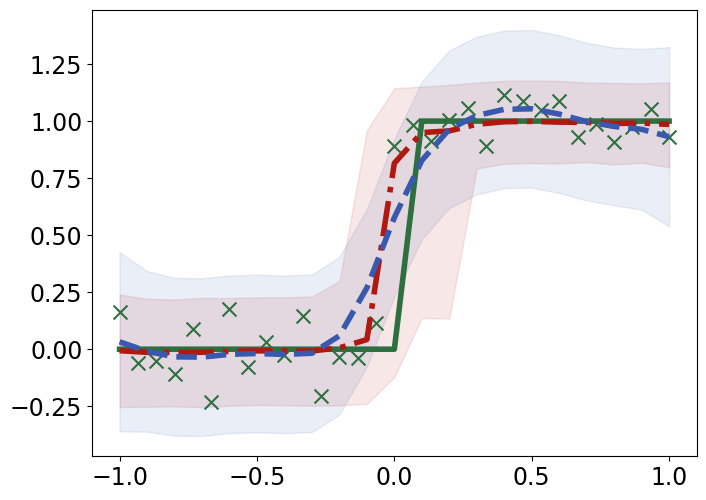

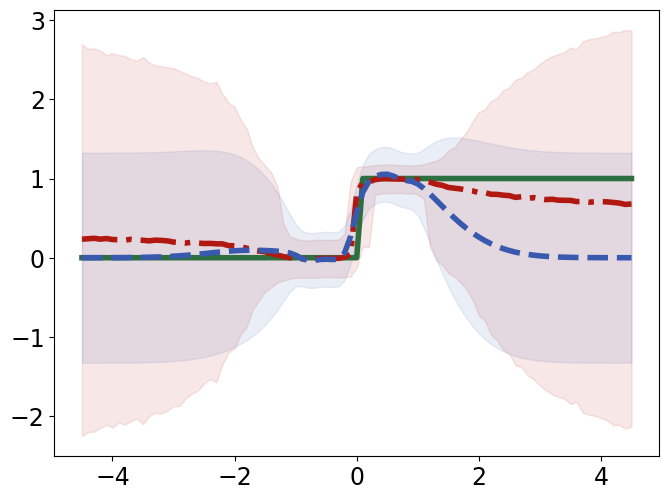

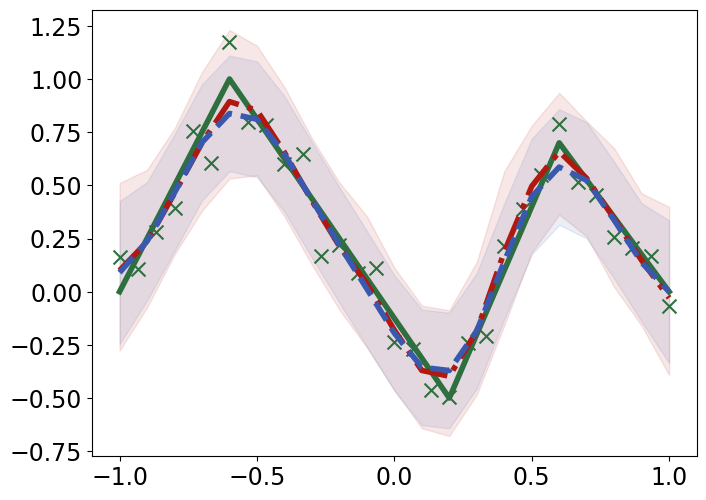

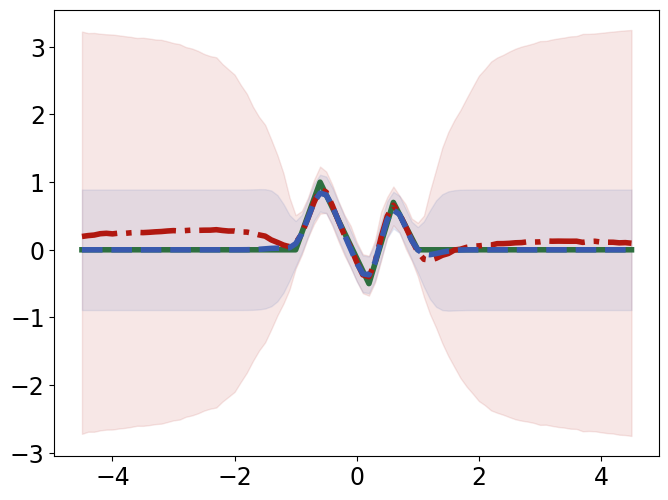

In [4]:
fname = ["linear", "quadratic", "step", "piecewiselinear"]

for n in [11, 31]:
# for n in 11:
    for i, f in enumerate([linear, quadratic, step, piecewise_linear]):
        X_train = np.linspace(-1,1, n)
        np.random.seed(1)
        epsilon = 0.1 *np.random.randn(n)
    
        y_train = f(X_train) + epsilon
    
    
        # TabPFN
        regressor = TabPFNRegressor(model_path = "/root/autodl-tmp/tabpfn/tabpfn-v2-regressor.ckpt")
        regressor.fit(X_train.reshape((-1,1)), y_train)
        X_test = np.arange(-4.5, 4.6, 0.1)
        y_pred = regressor.predict(X_test.reshape((-1,1)),output_type="full",quantiles=[0.025,0.975])
        
         
        # Define multiple kernel candidates
        kernel_candidates = [
            ConstantKernel() * RBF(),
            ConstantKernel() * Matern(nu=1.5),
            ConstantKernel() * RationalQuadratic(),
            ConstantKernel() * ExpSineSquared(),
            ConstantKernel() * RBF() + ConstantKernel() * Matern()
        ]
        alpha_candidates = [0.05, 0.1, 0.15, 0.2]
        # alpha_candidates = [0.00]
        
        best_score = -np.inf
        best_gpr = None
        
        for kernel in kernel_candidates:
            for alpha in alpha_candidates:
                gpr = GaussianProcessRegressor(kernel=kernel, alpha=alpha**2, n_restarts_optimizer=10)
                gpr.fit(X_train.reshape((-1,1)), y_train)
                score = gpr.log_marginal_likelihood()
                print(alpha, score)
                
                if score > best_score:
                    best_score = score
                    best_gpr = gpr
                    best_alpha = alpha
        
        y_pred_gp, y_cov_gp = gpr.predict(X_test.reshape((-1,1)), return_cov=True)


        # Interpolation
        fig = plt.figure()
        plt.plot(X_test[35:56], f(X_test[35:56]), linewidth=4, color="#2E6F40", label="True")
        plt.plot(X_test[35:56], y_pred['mean'][35:56], "-.", linewidth=4, color="#b11810", label="TabPFN")
        plt.fill_between(X_test[35:56], y_pred['quantiles'][0][35:56], y_pred['quantiles'][1][35:56],color="#b11810",alpha=0.1)
        plt.plot(X_test[35:56], y_pred_gp[35:56], "--", linewidth=4, color="#3859ad", label="GP")
        plt.fill_between(X_test[35:56], y_pred_gp[35:56] - 1.96 * np.sqrt(np.diag(y_cov_gp)+best_alpha**2)[35:56], y_pred_gp[35:56] + 1.96 * np.sqrt(np.diag(y_cov_gp)+best_alpha**2)[35:56], color="#3859ad", alpha=0.1)
        plt.scatter(X_train, y_train, s=100, marker="x", color="#2E6F40")
        if n == 11 and i==0:
            plt.legend()            
        plt.savefig("figure/interpolation_model_" + str(fname[i]) + "_n_" + str(n) + ".png", bbox_inches='tight')

        # Extrapolation
        fig = plt.figure()
        plt.plot(X_test, f(X_test), linewidth=4, color="#2E6F40", label="True")
        plt.plot(X_test, y_pred['mean'], "-.", linewidth=4, color="#b11810", label="TabPFN")
        plt.fill_between(X_test, y_pred['quantiles'][0], y_pred['quantiles'][1],color="#b11810",alpha=0.1)
        plt.plot(X_test, y_pred_gp, "--", linewidth=4, color="#3859ad", label="GP")
        plt.fill_between(X_test, y_pred_gp - 1.96 * np.sqrt(np.diag(y_cov_gp)+best_alpha**2), y_pred_gp + 1.96 * np.sqrt(np.diag(y_cov_gp)+best_alpha**2), color="#3859ad", alpha=0.1)
        # plt.scatter(X_train, y_train, s=100, marker="x", color="#2E6F40")
        # if n == 11 and i==0:
        #     plt.legend()            
        plt.savefig("figure/extrapolation_model_" + str(fname[i]) + "_n_" + str(n) + ".png", bbox_inches='tight')
